In [1]:
!pip install --quiet openslide-python opencv-python scikit-image pillow 
!pip install --quiet timm segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00


In [2]:
# ===================== 0) IMPORTS & CONFIG =====================
from pathlib import Path
import os, random, glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import openslide
import torch
from tqdm import tqdm

# --- reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- data paths (PANDA Kaggle) ---
TRAIN_DIR = Path("/kaggle/input/prostate-cancer-grade-assessment/train_images")
MASK_DIR  = Path("/kaggle/input/prostate-cancer-grade-assessment/train_label_masks")
OUT_DIR   = Path("/kaggle/working/panda_simple")
(OUT_DIR / "tiles").mkdir(parents=True, exist_ok=True)

# --- slide split sizes ---
N_TRAIN_SLIDES = 10
N_VAL_SLIDES   = 3
N_TEST_SLIDES  = 3

# --- tiling params ---
LEVEL        = 1          # slide pyramid level to read patches from
PATCH_SIZE   = 512
STRIDE       = 512
POS_MAX      = 500        # positive (tumor) tiles cap per slide
NEG_MAX      = 300        # negative (non-tumor) tiles cap per slide
TISSUE_MIN_PCT = 0.05     # skip mostly background tiles

# --- normalization constants (for later model work; unused in preview) ---
IMNET_MEAN   = (0.485, 0.456, 0.406)
IMNET_STD    = (0.229, 0.224, 0.225)

# --- output CSVs ---
TRAIN_CSV = OUT_DIR / "train.csv"
VAL_CSV   = OUT_DIR / "val.csv"
TEST_CSV  = OUT_DIR / "test.csv"


In [3]:
train_img_dir = "/kaggle/input/prostate-cancer-grade-assessment/train_images"
train_mask_dir = "/kaggle/input/prostate-cancer-grade-assessment/train_label_masks"
img_ids = os.listdir(train_img_dir)
mask_ids = os.listdir(train_mask_dir)

available_ids = []
for id in img_ids:
    mask_path = id[:-5] + "_mask.tiff"
    # print(mask_path)
    print
    if(id[-5:] == ".tiff" and mask_path in mask_ids):
        available_ids.append(id)
        

In [4]:
len(available_ids)

10516

In [5]:
out_dir = "/kaggle/working/"
try:
    os.mkdir(out_dir + "img")
    os.mkdir(out_dir + "mask")

except:
    pass

In [6]:
def tumor_bool_from_gray(mask_gray):

    u = set(np.unique(mask_gray).tolist())
    if any(x in u for x in (3,4,5)):
        return np.isin(mask_gray, [3,4,5])
    elif 2 in u:
        return (mask_gray == 2)
    else:
        return np.zeros_like(mask_gray, dtype=bool)

In [7]:
rows, pos, neg = [], 0, 0
patch_size = 512
stride = 512
pos_max = 1000
neg_max = 1000

for i in tqdm(range(15)):
    id = available_ids[i][:-5]
    slide_path = train_img_dir + "/"+ id + ".tiff"
    mask_path = train_mask_dir + "/"+ id + "_mask.tiff"
    # print(mask_path)
    img_slide = openslide.OpenSlide(slide_path)
    mask_slide = openslide.OpenSlide(mask_path)

    level = 0
    downslide = img_slide.level_downsamples[level]  # = 1
    W_img, H_img = img_slide.level_dimensions[level]
    W_mask, H_mask = mask_slide.level_dimensions[level]
    rx, ry   = (W_img / W_mask, H_img / H_mask)
    
    # print(img_slide.level_dimensions)
    # print(mask_slide.level_dimensions)
    # print(img_slide.level_dimensions[0])
    # break

    for y in range(0, H_img - patch_size +1, stride):
        if pos >= pos_max and neg >= neg_max :
            break
        for x in range(0, W_img - patch_size +1, stride):
            if pos >= pos_max and neg >= neg_max :
                break

            x0 = int(x * downslide)
            y0 = int(y * downslide)
            img = np.array(img_slide.read_region((x0, y0), level, (patch_size, patch_size)).convert("RGB"))

            mx0 = int(x0 * rx)
            my0 = int(y0 * ry)
            mask_rgba = np.array(mask_slide.read_region((mx0, my0), level, (patch_size, patch_size)))

            mask_gray = mask_rgba[..., 0]
            tumor = tumor_bool_from_gray(mask_gray)

            if(tumor.any()):
                img_path = out_dir + "img/" + f"{id}_x{x}_y{y}.png"
                mask_path = out_dir + "mask/" + f"{id}_x{x}_y{y}.png"

                cv2.imwrite(str(img_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
                cv2.imwrite(str(mask_path), tumor.astype(np.uint8) * 255)
                rows.append([str(img_path), str(mask_path), 1, id])
                pos += 1

            else:
                pass



            




100%|██████████| 15/15 [08:34<00:00, 34.32s/it]


In [8]:

df1 = pd.DataFrame(rows[:500], columns = ["img", "mask", "has_tumor", "id"])
df1= df1.sample(frac= 1.0, random_state= SEED).reset_index(drop= True)
df2 = pd.DataFrame(rows[500:600], columns = ["img", "mask", "has_tumor", "id"])
df2= df2.sample(frac= 1.0, random_state= SEED).reset_index(drop= True)

# data_csv = out_dir + "train.csv"
df1.to_csv(out_dir + "train.csv", index = False)
df2.to_csv(out_dir + "val.csv", index = False)

# from sklearn.model_selection import train_test_split

# train_df, _ = train_test_split(df, test_size=0.2, random_state=42)  # 80% train, 20% temp
# val_df, test_df = train_test_split(_, test_size=0.5, random_state=42)


In [9]:
# ===================== 1) DATASET, UNET, LOSSES =====================
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt
from pathlib import Path

# Reuse OUT_DIR, IMNET_MEAN/STD from your previous cells
NUM_WORKERS = 0  # set >0 on Kaggle if you like

class SegDataset(Dataset):
    def __init__(self, manifest_csv, augment=False):
        self.df = pd.read_csv(manifest_csv).dropna(subset=["img","mask"]).reset_index(drop=True)
        self.augment = augment
        self.mean = np.array(IMNET_MEAN, dtype=np.float32)
        self.std  = np.array(IMNET_STD,  dtype=np.float32)

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(str(row["img"])), cv2.COLOR_BGR2RGB) 
        msk = cv2.imread(str(row["mask"]), cv2.IMREAD_GRAYSCALE)
        if img is None or msk is None:
            raise FileNotFoundError(f"Bad path at index {i}: {row['img']} | {row['mask']}")

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.ascontiguousarray(np.fliplr(img)); msk = np.ascontiguousarray(np.fliplr(msk))
            if np.random.rand() < 0.5:
                img = np.ascontiguousarray(np.flipud(img)); msk = np.ascontiguousarray(np.flipud(msk))

        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std
        img = np.transpose(img, (2,0,1))

        msk = (msk.astype(np.float32) / 255.0)[None]

        return torch.from_numpy(img), torch.from_numpy(msk)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.seq(x)

class UNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        self.inc   = DoubleConv(3, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 256))

        self.up1   = nn.ConvTranspose2d(256, 256, 2, stride=2)
        self.dec1  = DoubleConv(256+256, 256)
        self.up2   = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2  = DoubleConv(128+128, 128)
        self.up3   = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3  = DoubleConv(64+64, 64)
        self.up4   = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec4  = DoubleConv(32+32, 32)

        self.outc  = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x  = self.up1(x5); x = torch.cat([x, x4], dim=1); x = self.dec1(x)
        x  = self.up2(x);  x = torch.cat([x, x3], dim=1); x = self.dec2(x)
        x  = self.up3(x);  x = torch.cat([x, x2], dim=1); x = self.dec3(x)
        x  = self.up4(x);  x = torch.cat([x, x1], dim=1); x = self.dec4(x)
        return self.outc(x)

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2.0 * (probs * targets).sum(dim=(2,3))
    den = (probs.pow(2) + targets.pow(2)).sum(dim=(2,3)) + eps
    return (1.0 - num / den).mean()


In [10]:
def train_model(model, train_csv, val_csv=None, ckpt_path="model_best.pth",
                epochs=30, batch_size=14, lr=2e-4, num_workers=0):

    # datasets & loaders
    train_ds = SegDataset(train_csv, augment=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # val_loader = None
    # if val_csv is not None:
    #     val_ds = SegDataset(val_csv, augment=False)
    #     val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    bce = nn.BCEWithLogitsLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # best_val = float("inf")

    for epoch in range(1, epochs+1):
        # --- train ---
        model.train(); tr_loss = 0.0
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            logits = model(imgs)
            loss = 0.5*bce(logits, msks) + 0.5*dice_loss(logits, msks)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * imgs.size(0)
        tr_loss /= len(train_loader.dataset)

        # --- val ---
        # va_loss = None
        # if val_loader is not None:
        #     model.eval(); va_loss = 0.0
        #     with torch.no_grad():
        #         for imgs, msks in val_loader:
        #             imgs, msks = imgs.to(device), msks.to(device)
        #             logits = model(imgs)
        #             loss = 0.5*bce(logits, msks) + 0.5*dice_loss(logits, msks)
        #             va_loss += loss.item() * imgs.size(0)
        #     va_loss /= len(val_loader.dataset)

        
        print(f"Epoch {epoch:02d} | train={tr_loss:.4f}")
        torch.save(model.state_dict(), ckpt_path)
        print(" model saved ")


In [11]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = SegDataset(out_dir + "/train.csv")
val_ds   = SegDataset(out_dir + "/val.csv")

# model = UNet().to(device)
# train_model(model, train_csv=out_dir/"train.csv", val_csv=out_dir/"val.csv", ckpt_path=out_dir/"unet_best.pth", epochs=30)


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p, dilation=d, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.ReLU(inplace=True)
    def forward(self, x): return self.act(self.bn(self.conv(x)))

class OS16Backbone(nn.Module):

    def __init__(self, in_ch=3, base=32):
        super().__init__()

        self.s1 = nn.Sequential(
            ConvBNReLU(in_ch, base, 3, 2, 1),
            ConvBNReLU(base, base, 3, 1, 1),
        )

        self.s2 = nn.Sequential(
            ConvBNReLU(base, base*2, 3, 2, 1),
            ConvBNReLU(base*2, base*2, 3, 1, 1),
        )
         
        self.s3 = nn.Sequential(
            ConvBNReLU(base*2, base*4, 3, 2, 1),
            ConvBNReLU(base*4, base*4, 3, 1, 1),
        )
         
        self.s4 = nn.Sequential(
            ConvBNReLU(base*4, base*8, 3, 2, 1),
            ConvBNReLU(base*8, base*8, 3, 1, 1),
            ConvBNReLU(base*8, base*8, 3, 1, 1),
        )
        self.low_planes  = base*2
        self.high_planes = base*8

    def forward(self, x):
        x  = self.s1(x)     
        l1 = self.s2(x)      
        x  = self.s3(l1)    
        h  = self.s4(x)     
        return l1, h

In [13]:
class BaseED(nn.Module):
    def __init__(self, num_classes=1, base=32, dec_mid=128):
        super().__init__()
        self.enc = OS16Backbone(base=base)
        self.dec = nn.Sequential(
            ConvBNReLU(self.enc.high_planes, dec_mid, 3, 1, 1),
            ConvBNReLU(dec_mid, dec_mid, 3, 1, 1),
        )
        self.cls = nn.Conv2d(dec_mid, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[-2:]
        _, high = self.enc(x)
        y = self.dec(high)
        y = self.cls(y)
        return F.interpolate(y, size=(H, W), mode='bilinear', align_corners=False)


In [14]:
class DeepLabV1_Simple(nn.Module):

    def __init__(self, num_classes=1, base=32, rates=(2,4,8)):
        super().__init__()
        self.enc = OS16Backbone(base=base)
        
        blocks = []
        for r in rates:
            blocks += [ConvBNReLU(self.enc.high_planes, self.enc.high_planes, 3, 1, p=r, d=r)]
        self.head = nn.Sequential(
            ConvBNReLU(256, 256, 3, 1, p=2, d=2),
            ConvBNReLU(256, 256, 3, 1, p=4, d=8),
            ConvBNReLU(256, 256, 3, 1, p=8, d=8))
        
        self.cls  = nn.Conv2d(self.enc.high_planes, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[-2:]
        _, high = self.enc(x)
        y = self.head(high)
        y = self.cls(y)
        return F.interpolate(y, size=(H, W), mode='bilinear', align_corners=False)


In [15]:
class DeepLabV2_Simple(nn.Module):
    """OS=16 encoder + ASPP (no image-level branch) → logits."""
    def __init__(self, num_classes=1, base=64, aspp_out=256, rates=(6,12,18)):
        super().__init__()
        self.enc = OS16Backbone(base=base)
        C = self.enc.high_planes; O = aspp_out
        # inline ASPP branches
        self.aspp_b1 = nn.Sequential(nn.Conv2d(C, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b2 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[0], dilation=rates[0], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b3 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[1], dilation=rates[1], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b4 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[2], dilation=rates[2], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_proj = nn.Sequential(nn.Conv2d(O*4, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.cls = nn.Conv2d(O, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[-2:]
        _, high = self.enc(x)
        y = torch.cat([self.aspp_b1(high), self.aspp_b2(high), self.aspp_b3(high), self.aspp_b4(high)], dim=1)
        y = self.aspp_proj(y)
        y = self.cls(y)
        return F.interpolate(y, size=(H, W), mode='bilinear', align_corners=False)


In [16]:
class DeepLabV3_Simple(nn.Module):
    """OS=16 encoder + (ASPP + image-level pooling) → logits."""
    def __init__(self, num_classes=1, base=64, aspp_out=256, rates=(6,12,18)):
        super().__init__()
        self.enc = OS16Backbone(base=base)
        C = self.enc.high_planes; O = aspp_out
        # ASPP branches
        self.aspp_b1 = nn.Sequential(nn.Conv2d(C, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b2 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[0], dilation=rates[0], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b3 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[1], dilation=rates[1], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b4 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[2], dilation=rates[2], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_proj = nn.Sequential(nn.Conv2d(O*4, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        # image-level branch
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.img_proj = nn.Sequential(nn.Conv2d(C, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        # fuse + classifier
        self.fuse_proj = nn.Sequential(nn.Conv2d(O*2, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.cls = nn.Conv2d(O, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[-2:]
        _, high = self.enc(x)
        aspp = self.aspp_proj(torch.cat([self.aspp_b1(high), self.aspp_b2(high), self.aspp_b3(high), self.aspp_b4(high)], dim=1))
        # image-level pool resized to ASPP map
        il  = self.img_proj(self.pool(high))
        il  = F.interpolate(il, size=aspp.shape[-2:], mode='bilinear', align_corners=False)
        y   = self.fuse_proj(torch.cat([aspp, il], dim=1))
        y   = self.cls(y)
        return F.interpolate(y, size=(H, W), mode='bilinear', align_corners=False)


In [17]:
class DeepLabV3Plus_Simple(nn.Module):
    """OS=16 encoder + (ASPP + image pooling) encoder head + lightweight decoder with low-level fusion."""
    def __init__(self, num_classes=1, base=64, aspp_out=256, low_proj=48, rates=(6,12,18)):
        super().__init__()
        self.enc = OS16Backbone(base=base)
        C = self.enc.high_planes; O = aspp_out

        # ASPP
        self.aspp_b1 = nn.Sequential(nn.Conv2d(C, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b2 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[0], dilation=rates[0], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b3 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[1], dilation=rates[1], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_b4 = nn.Sequential(nn.Conv2d(C, O, 3, padding=rates[2], dilation=rates[2], bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.aspp_proj = nn.Sequential(nn.Conv2d(O*4, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        # image-level
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.img_proj = nn.Sequential(nn.Conv2d(C, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))
        self.fuse_proj = nn.Sequential(nn.Conv2d(O*2, O, 1, bias=False), nn.BatchNorm2d(O), nn.ReLU(inplace=True))

        # low-level projection & decoder
        self.low_proj = nn.Sequential(nn.Conv2d(self.enc.low_planes, low_proj, 1, bias=False),
                                      nn.BatchNorm2d(low_proj), nn.ReLU(inplace=True))
        self.dec1 = nn.Sequential(ConvBNReLU(O + low_proj, 128, 3, 1, 1),
                                  ConvBNReLU(128, 128, 3, 1, 1))
        self.cls  = nn.Conv2d(128, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[-2:]
        low, high = self.enc(x)

        aspp = self.aspp_proj(torch.cat([self.aspp_b1(high), self.aspp_b2(high), self.aspp_b3(high), self.aspp_b4(high)], dim=1))
        il   = self.img_proj(self.pool(high))
        il   = F.interpolate(il, size=aspp.shape[-2:], mode='bilinear', align_corners=False)
        head = self.fuse_proj(torch.cat([aspp, il], dim=1))              # /16

        head = F.interpolate(head, size=low.shape[-2:], mode='bilinear', align_corners=False)  # /4
        fuse = torch.cat([head, self.low_proj(low)], dim=1)
        dec  = self.dec1(fuse)
        y    = self.cls(dec)
        return F.interpolate(y, size=(H, W), mode='bilinear', align_corners=False)

In [18]:
unet_model = UNet().to(device)
BaseED_model = BaseED().to(device)
v1_model = DeepLabV1_Simple().to(device)
v2_model = DeepLabV2_Simple().to(device)
v3_model = DeepLabV3_Simple().to(device)
v3_plus_model = DeepLabV3Plus_Simple().to(device)

train_model(unet_model, train_csv=out_dir + "train.csv", val_csv=out_dir +"val.csv", ckpt_path=out_dir +"unet_best.pth", epochs=30)
train_model(BaseED_model, train_csv=out_dir + "train.csv", val_csv=out_dir + "val.csv", ckpt_path=out_dir + "BaseED_best.pth", epochs=30)
train_model(v1_model, train_csv=out_dir + "train.csv", val_csv=out_dir + "val.csv", ckpt_path=out_dir + "v1_best.pth", epochs=30)
train_model(v2_model, train_csv=out_dir + "train.csv", val_csv=out_dir + "val.csv", ckpt_path=out_dir + "v2_best.pth", epochs=30)
train_model(v3_model, train_csv=out_dir + "train.csv", val_csv=out_dir + "val.csv", ckpt_path=out_dir + "v3_best.pth", epochs=30)
train_model(v3_plus_model, train_csv=out_dir + "train.csv", val_csv=out_dir + "val.csv", ckpt_path=out_dir + "v3_plus_best.pth", epochs=30)

Epoch 01 | train=0.5514
 model saved 
Epoch 02 | train=0.4590
 model saved 
Epoch 03 | train=0.4275
 model saved 
Epoch 04 | train=0.4084
 model saved 
Epoch 05 | train=0.3927
 model saved 
Epoch 06 | train=0.3684
 model saved 
Epoch 07 | train=0.3527
 model saved 
Epoch 08 | train=0.3390
 model saved 
Epoch 09 | train=0.3289
 model saved 
Epoch 10 | train=0.3151
 model saved 
Epoch 11 | train=0.3028
 model saved 
Epoch 12 | train=0.2921
 model saved 
Epoch 13 | train=0.2764
 model saved 
Epoch 14 | train=0.2681
 model saved 
Epoch 15 | train=0.2629
 model saved 
Epoch 16 | train=0.2553
 model saved 
Epoch 17 | train=0.2472
 model saved 
Epoch 18 | train=0.2431
 model saved 
Epoch 19 | train=0.2336
 model saved 
Epoch 20 | train=0.2294
 model saved 
Epoch 21 | train=0.2184
 model saved 
Epoch 22 | train=0.2116
 model saved 
Epoch 23 | train=0.2147
 model saved 
Epoch 24 | train=0.2033
 model saved 
Epoch 25 | train=0.2089
 model saved 
Epoch 26 | train=0.1990
 model saved 
Epoch 27 | t

In [19]:
# ===================== 3) TEST & SHOW (Patch | Prediction | Ground truth) =====================
def preprocess_rgb_uint8(img_rgb):
    x = img_rgb.astype(np.float32) / 255.0
    x = (x - np.array(IMNET_MEAN, np.float32)) / np.array(IMNET_STD, np.float32)
    x = np.transpose(x, (2,0,1))
    return torch.from_numpy(x)[None]

def to_red(mask01):
    mk = (mask01.astype(np.uint8) * 255)
    return np.dstack([mk, np.zeros_like(mk), np.zeros_like(mk)])

@torch.no_grad()
def test_and_show(ckpt_path, df_csv, k=8, threshold=0.5, title="U-Net results"):
    # load model
    model = UNet().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    df = pd.read_csv(df_csv)
    if len(df) == 0:
        print("Empty CSV:", df_csv); return

    # prefer positives if available
    pos = df[df["has_tumor"] == 1]
    if len(pos) >= k:
        sel = pos.sample(k, random_state=SEED)
    else:
        need = min(k - len(pos), len(df))
        sel = pd.concat([pos, df.sample(need, random_state=SEED)], axis=0).reset_index(drop=True)

    rows = len(sel)
    plt.figure(figsize=(12, 3.2*rows))
    for i, r in enumerate(sel.itertuples(index=False)):
        im = cv2.cvtColor(cv2.imread(r.img), cv2.COLOR_BGR2RGB)
        gt = cv2.imread(r.mask, cv2.IMREAD_GRAYSCALE)
        if im is None or gt is None:
            continue

        prob = torch.sigmoid(model(preprocess_rgb_uint8(im).to(device)))[0,0].cpu().numpy()
        pred01 = (prob >= threshold).astype(np.uint8)

        ax1 = plt.subplot(rows, 3, 3*i+1); ax1.imshow(im);                ax1.set_title(f"Patch {i+1}"); ax1.axis('off')
        ax2 = plt.subplot(rows, 3, 3*i+2); ax2.imshow(to_red(pred01));    ax2.set_title("Prediction");   ax2.axis('off')
        ax3 = plt.subplot(rows, 3, 3*i+3); ax3.imshow(to_red(gt>127));    ax3.set_title("Ground truth"); ax3.axis('off')

    plt.suptitle(title); plt.tight_layout(); plt.show()


In [20]:
# ===================== 4) RUN QUICK TEST PREVIEW =====================
# csv_to_use = OUT_DIR/"test.csv" if (OUT_DIR/"test.csv").exists() else out_dir + "val.csv"
# test_and_show(CKPT_UNET, csv_to_use, k=8, threshold=0.5, title="")

In [21]:
import torch, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# assumes these classes already exist in your session:
# UNet, DeepLabV1_Simple, DeepLabV2_Simple, DeepLabV3_Simple, DeepLabV3Plus_Simple
# and a global `device` (cuda/cpu)

IMNET_MEAN = (0.485, 0.456, 0.406)
IMNET_STD  = (0.229, 0.224, 0.225)

def _preprocess_rgb_uint8(im_rgb):
    x = im_rgb.astype(np.float32) / 255.0
    x = (x - np.array(IMNET_MEAN, np.float32)) / np.array(IMNET_STD, np.float32)
    x = np.transpose(x, (2,0,1))  # CHW
    return torch.from_numpy(x)[None]  # [1,3,H,W]

def _to_red(mask01):
    mk = (mask01.astype(np.uint8) * 255)
    return np.dstack([mk, np.zeros_like(mk), np.zeros_like(mk)])

@torch.no_grad()
def show_patch_comparison(
    test_csv,
    ckpt_unet,
    ckpt_v1,
    ckpt_v2,
    ckpt_v3,
    ckpt_v3plus,
    k=6,
    threshold=0.5,
):
    """Displays rows of: Patch | GT | UNet | v1 | v2 | v3 | v3+ on k samples (prefer positives)."""
    # build models and load weights
    model_fns = {
        "UNet": UNet,
        "v1":   DeepLabV1_Simple,
        "v2":   DeepLabV2_Simple,
        "v3":   DeepLabV3_Simple,
        "v3+":  DeepLabV3Plus_Simple,
    }
    ckpts = {
        "UNet": ckpt_unet,
        "v1":   ckpt_v1,
        "v2":   ckpt_v2,
        "v3":   ckpt_v3,
        "v3+":  ckpt_v3plus,
    }
    models = {}
    for name, ctor in model_fns.items():
        p = ckpts[name]
        assert p is not None and Path(p).exists(), f"Checkpoint for {name} not found: {p}"
        m = ctor().to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval()
        models[name] = m

    # pick samples
    df = pd.read_csv(test_csv)
    assert len(df) > 0, f"Empty CSV: {test_csv}"
    pos = df[df["has_tumor"] == 1]
    if len(pos) >= k:
        sel = pos.sample(k, random_state=42).reset_index(drop=True)
    else:
        need = min(k - len(pos), len(df))
        sel = pd.concat([pos, df.sample(need, random_state=42)], axis=0).reset_index(drop=True)

    # plot
    cols = 7  # Patch | GT | UNet | v1 | v2 | v3 | v3+
    rows = len(sel)
    plt.figure(figsize=(3.0*cols, 3.0*rows))

    for i, r in enumerate(sel.itertuples(index=False)):
        # load patch + GT
        im  = cv2.cvtColor(cv2.imread(r.img), cv2.COLOR_BGR2RGB)
        gt  = cv2.imread(r.mask, cv2.IMREAD_GRAYSCALE)
        xin = _preprocess_rgb_uint8(im).to(device)

        # col 1: patch
        ax = plt.subplot(rows, cols, i*cols+1); ax.imshow(im); ax.set_title("Patch"); ax.axis('off')
        # col 2: GT
        ax = plt.subplot(rows, cols, i*cols+2); ax.imshow(_to_red(gt>127)); ax.set_title("GT"); ax.axis('off')

        # model columns
        for j, name in enumerate(["UNet","v1","v2","v3","v3+"], start=3):
            prob = torch.sigmoid(models[name](xin))[0,0].cpu().numpy()
            pred = (prob >= threshold).astype(np.uint8)
            ax = plt.subplot(rows, cols, i*cols+j); ax.imshow(_to_red(pred)); ax.set_title(name); ax.axis('off')

    plt.tight_layout(); plt.show()


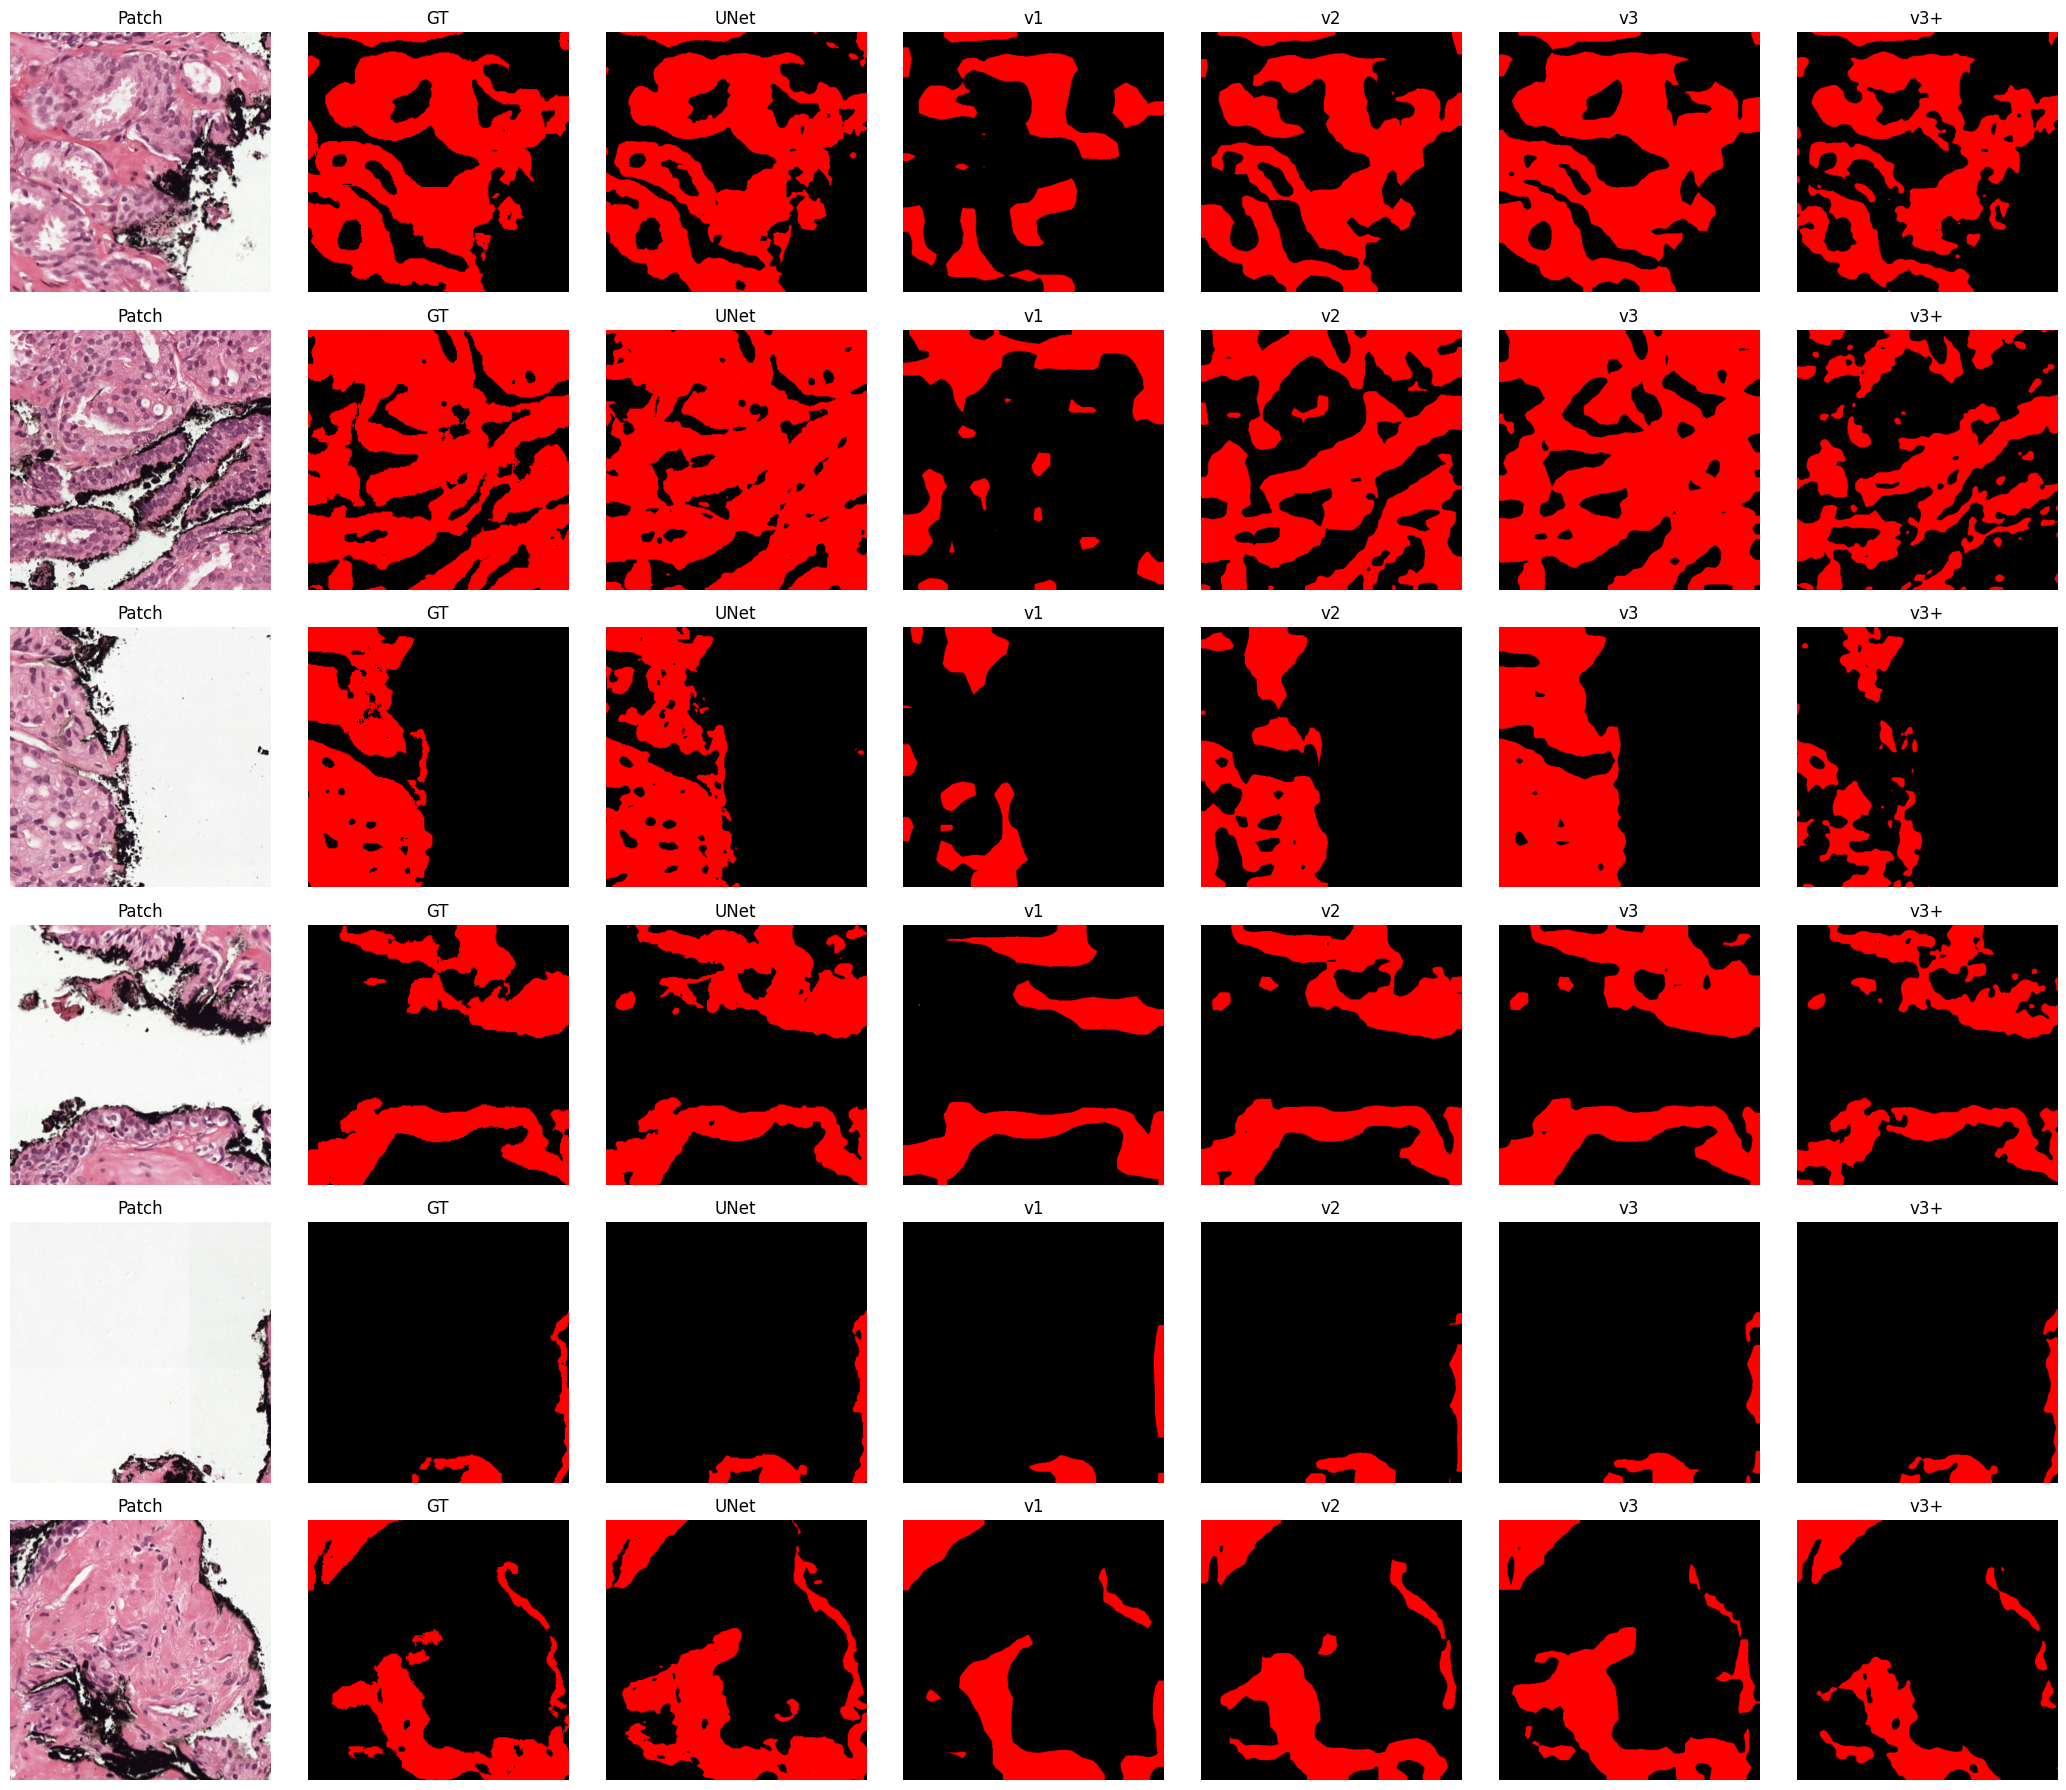

In [22]:
show_patch_comparison(
    test_csv = out_dir + "val.csv",
    ckpt_unet   = out_dir + "unet_best.pth",
    ckpt_v1     = out_dir + "v1_best.pth",
    ckpt_v2     = out_dir + "v2_best.pth",
    ckpt_v3     = out_dir + "v3_best.pth",
    ckpt_v3plus = out_dir + "v3_plus_best.pth",
    k=6, threshold=0.5,
)
